In [42]:
import pandas as pd
import plotly.express as plt
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt

penurl = "https://raw.githubusercontent.com/dataprofessor/data/refs/heads/master/penguins_cleaned.csv"
url = "https://raw.githubusercontent.com/nkmwicz/data-for-students/refs/heads/main/soccer-players.csv"

df = pd.read_csv(url)
penguins = pd.read_csv(penurl)
df.head()

,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,foot,height_in_cm,contract_expiration_date,agent_name,image_url,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,...,right,184.0,NaN,ASBW Sport Marketing,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/miroslav-klose...,IT1,Società Sportiva Lazio S.p.A.,1000000.0,30000000.0
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,...,left,190.0,NaN,Neubauer 13 GmbH,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/roman-weidenfe...,L1,Borussia Dortmund,750000.0,8000000.0
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,...,NaN,NaN,NaN,CSKA-AS-23 Ltd.,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/dimitar-berbat...,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000.0,34500000.0
3,77,NaN,Lúcio,Lúcio,2012,506,lucio,Brazil,Brasília,Brazil,...,NaN,NaN,NaN,NaN,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/lucio/profil/s...,IT1,Juventus Football Club,200000.0,24500000.0
4,80,Tom,Starke,Tom Starke,2017,27,tom-starke,East Germany (GDR),Freital,Germany,...,right,194.0,NaN,IFM,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/tom-starke/pro...,L1,FC Bayern München,100000.0,3000000.0


In [43]:
df = df[["position", "date_of_birth", "name"]]
df.head()

,position,date_of_birth,name
0,Attack,1978-06-09 00:00:00,Miroslav Klose
1,Goalkeeper,1980-08-06 00:00:00,Roman Weidenfeller
2,Attack,1981-01-30 00:00:00,Dimitar Berbatov
3,Defender,1978-05-08 00:00:00,Lúcio
4,Goalkeeper,1981-03-18 00:00:00,Tom Starke


In [44]:
df["bmonth"] = pd.to_datetime(df["date_of_birth"])
df["bmonth"]

0       1978-06-09
1       1980-08-06
2       1981-01-30
3       1978-05-08
4       1981-03-18
           ...    
32398   2003-02-04
32399   2007-09-06
32400   2005-02-19
32401   2006-01-01
32402   2006-06-05
Name: bmonth, Length: 32403, dtype: datetime64[ns]

In [45]:
df["bmonth"] = df["bmonth"].dt.month
df["bmonth"]

0        6.0
1        8.0
2        1.0
3        5.0
4        3.0
        ... 
32398    2.0
32399    9.0
32400    2.0
32401    1.0
32402    6.0
Name: bmonth, Length: 32403, dtype: float64

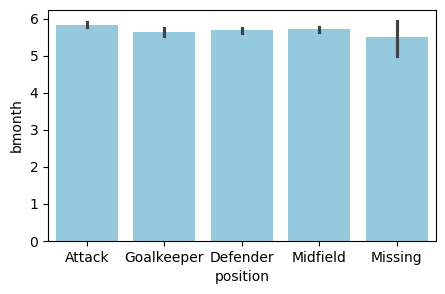

In [46]:
plt.figure(figsize=(5, 3))
bar = sns.barplot(data=df, x="position", y="bmonth", color="skyblue")

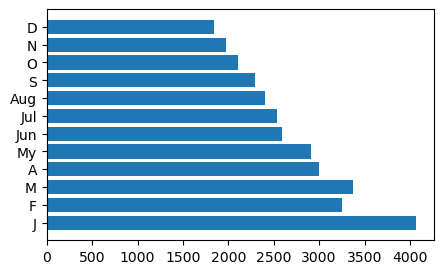

In [49]:
df = df.dropna(subset=["position", "bmonth"])
months = sorted(df["bmonth"].unique())
months
month_counts = [df.loc[df["bmonth"] == m, "bmonth"].count() for m in months]
m_names = ["J", "F", "M", "A", "My", "Jun", "Jul", "Aug", "S", "O", "N", "D"]
m_names = [m_names [idx] for idx, _ in enumerate(months)]
plt.figure(figsize=(5,3))
plt.barh(y=m_names, width=month_counts)
plt.show()

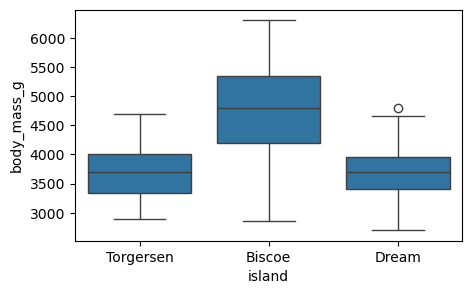

In [50]:
plt.figure(figsize = (5,3))
box = sns.boxplot(data=penguins, x="island", y="body_mass_g")


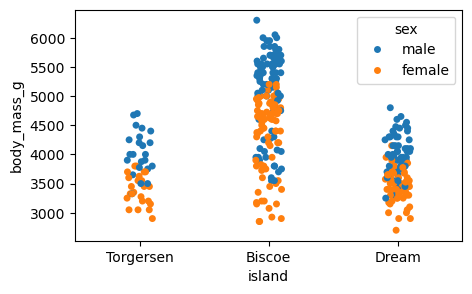

In [52]:
plt.figure(figsize=(5,3))
strip = sns.stripplot(data=penguins, x="island", y="body_mass_g", hue="sex")

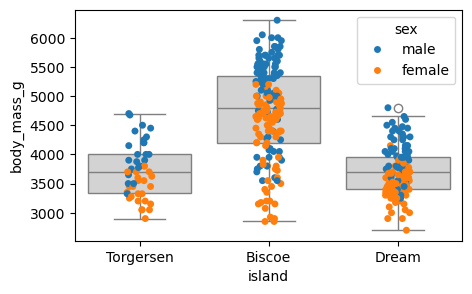

In [58]:
plt.figure(figsize = (5,3))
box = sns.boxplot(data=penguins, x="island", y="body_mass_g", color = "lightgray")
strip = sns.stripplot(data=penguins, x="island", y="body_mass_g", hue="sex")

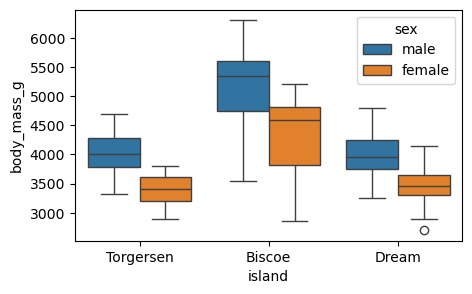

In [60]:
plt.figure(figsize = (5,3))
box = sns.boxplot(data=penguins, x="island", y="body_mass_g", hue = "sex")

<Figure size 500x300 with 0 Axes>

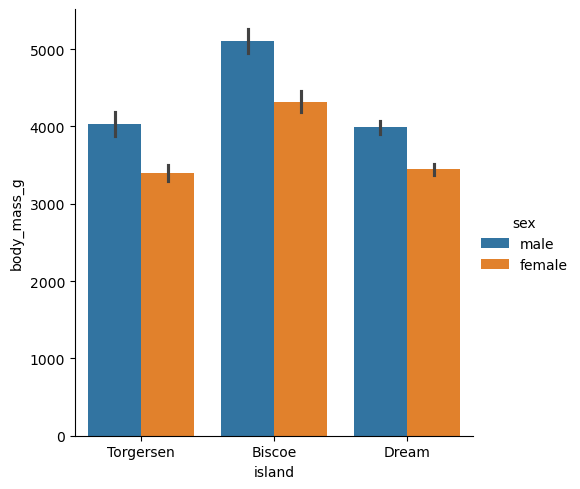

In [65]:
plt.figure(figsize=(5,3))
sns.catplot(data=penguins, x="island", y="body_mass_g", hue="sex", kind="bar")

<Figure size 500x300 with 0 Axes>

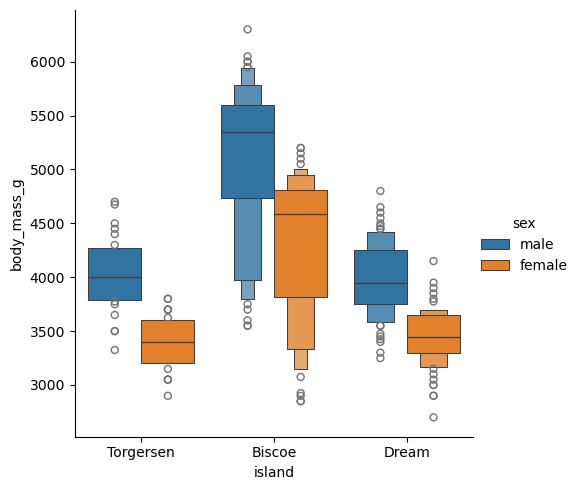

In [66]:
plt.figure(figsize=(5,3))
sns.catplot(data=penguins, x="island", y="body_mass_g", hue="sex", kind="boxen")

<Figure size 500x300 with 0 Axes>

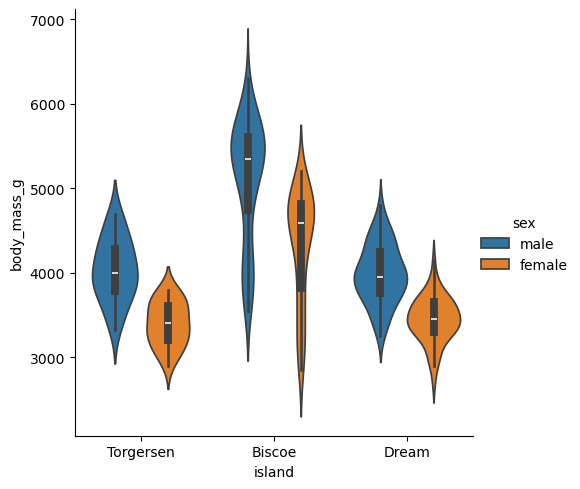

In [69]:
plt.figure(figsize=(5,3))
sns.catplot(data=penguins, x="island", y="body_mass_g", hue="sex", kind="violin")

<Figure size 500x300 with 0 Axes>

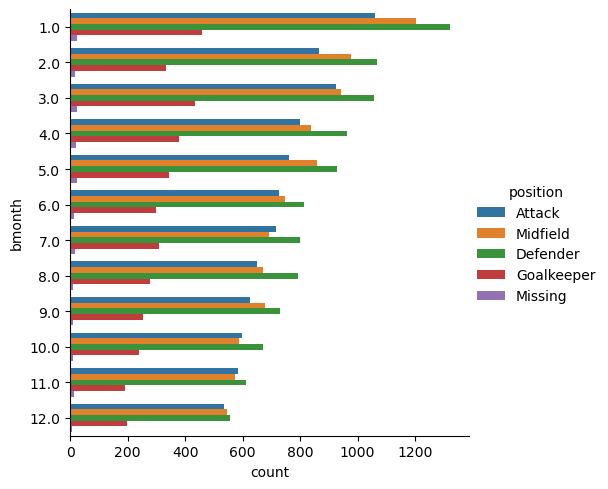

In [74]:
plt.figure(figsize=(5,3))
sns.catplot(data=df, y="bmonth", hue="position", kind="count")


<Figure size 500x300 with 0 Axes>

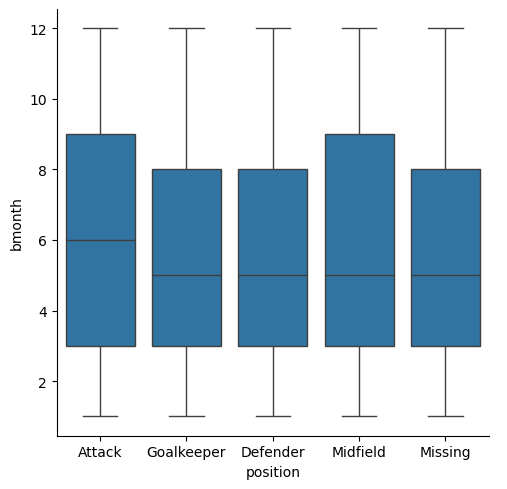

In [75]:
plt.figure(figsize=(5,3))
sns.catplot(data=df, x="position", y="bmonth", kind="box")

In [78]:
df["is_attacker"] = df["position"] == "Attack" 
att_all = [df.loc[df["is_attacker"] == t, "bmonth"] for t in [True, False]]
t, p = stats.ttest_ind(*att_all)
print(f"t={t:.4f}, p={p:.4f}")

t=3.3887, p=0.0007


In [80]:
deg_f = len(att_all[0]) + len(att_all[1]) - 2
alpha = 0.05
critical = stats.t.ppf(1-alpha/2, deg_f)
print(critical)


1.9600373095839665


<Axes: xlabel='is_attacker', ylabel='bmonth'>

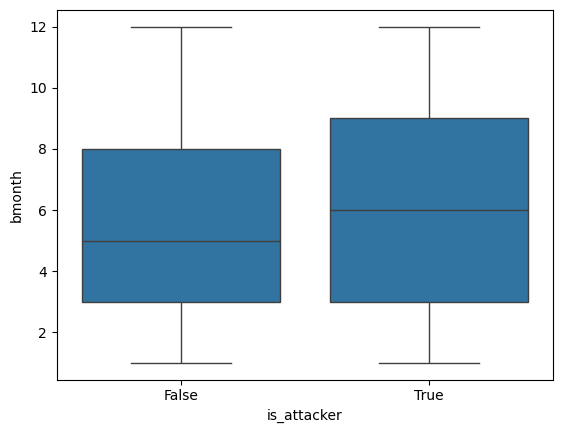

In [81]:
sns.boxplot(data=df, x="is_attacker", y="bmonth")
mean_diff = att_all[0] 

In [84]:
positions = df["position"].unique()
pos_data = [df.loc[df["position"]== pos, "bmonth"] for pos in positions]
f, p = stats.f_oneway(*pos_data)
dfb = len(pos_data) - 1
dfw = len(df) - len(pos_data)
critical = stats.f.ppf(1-alpha, dfb, dfw)
print(f"f={f:.4f}, p={p:.4f}, critical={critical:.4f}, p={p:.4f}")

f=3.2134, p=0.0120, critical=2.3722, p=0.0120


In [85]:
tukey = stats.tukey_hsd(*pos_data)
print(tukey)
print(positions)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)      0.183     0.049     0.001     0.366
 (0 - 2)      0.146     0.027     0.011     0.281
 (0 - 3)      0.124     0.103    -0.014     0.263
 (0 - 4)      0.337     0.686    -0.365     1.040
 (1 - 0)     -0.183     0.049    -0.366    -0.001
 (1 - 2)     -0.037     0.979    -0.216     0.141
 (1 - 3)     -0.059     0.902    -0.240     0.122
 (1 - 4)      0.154     0.977    -0.558     0.866
 (2 - 0)     -0.146     0.027    -0.281    -0.011
 (2 - 1)      0.037     0.979    -0.141     0.216
 (2 - 3)     -0.022     0.992    -0.155     0.112
 (2 - 4)      0.191     0.946    -0.510     0.893
 (3 - 0)     -0.124     0.103    -0.263     0.014
 (3 - 1)      0.059     0.902    -0.122     0.240
 (3 - 2)      0.022     0.992    -0.112     0.155
 (3 - 4)      0.213     0.922    -0.489     0.915
 (4 - 0)     -0.337     0.686    -1.040     0.365
 (4 - 1)     -0.154     0.977    -0.866     